In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import FunctionTransformer, StandardScaler


df = pd.read_excel("./Concrete_Data.xls")
df.drop_duplicates(keep='last', inplace=True)
df_clean = df.copy()
X = df_clean.iloc[:, 0:8]
y = df_clean.iloc[:, -1:]


Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)'],
      dtype='object')


In [2]:
y = pd.cut(y['Concrete compressive strength(MPa, megapascals) '],
                              bins=[-float("inf"), 25, 40, float("inf")],
                              labels=[0, 1, 2])

In [ ]:
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np

outer_kf = KFold(n_splits=10, shuffle=True)
inner_kf = KFold(n_splits=5, shuffle=True)

Cs = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]

results = { 
    "fold": [], 
    "method": [], 
    "x_i": [], 
    "E_test": [],
    "y_true": [],
    "y_pred": [],
    "Accuracy": []
}


fold = 0

for train_index, test_index in outer_kf.split(X, y):
    X_tr_raw, X_te_raw = X.iloc[train_index], X.iloc[test_index]
    y_tr, y_te = y.iloc[train_index], y.iloc[test_index]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)
    X_te = scaler.transform(X_te_raw)

    best_C = None
    best_val_err = np.inf

    for C in Cs:
        val_errs = []

        for in_tr, in_val in inner_kf.split(X_tr, y_tr):

            # Inner split
            X_inner_tr_raw = X_tr[in_tr]
            X_inner_val_raw = X_tr[in_val]
            y_inner_tr = y_tr.iloc[in_tr]
            y_inner_val = y_tr.iloc[in_val]

            # Inner scaler
            sc_in = StandardScaler()
            X_inner_tr = sc_in.fit_transform(X_inner_tr_raw)
            X_inner_val = sc_in.transform(X_inner_val_raw)

            model = LogisticRegression(C=C, random_state=42)
            model.fit(X_inner_tr, y_inner_tr)
            pred = model.predict(X_inner_val)
            val_errs.append(np.mean(pred != y_inner_val))

        mean_val = np.mean(val_errs)
        if mean_val < best_val_err:
            best_val_err = mean_val
            best_C = C

    # Retrain on full outer training set
    model = LogisticRegression(C=best_C, random_state=42, multi_class='multinomial')
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    accuracy = np.mean(y_pred == y_te)
    results["Accuracy"].append(accuracy) 
    results["fold"].append(fold)
    results["method"].append("LogReg")
    results["x_i"].append(best_C)
    results["E_test"].append(np.mean(y_pred != y_te))
    results["y_true"].append(y_te.values)
    results["y_pred"].append(y_pred)


    best_k = None
    best_val_err = np.inf

    for k in k_values:
        val_errs = []

        for in_tr, in_val in inner_kf.split(X_tr, y_tr):

            X_inner_tr_raw = X_tr[in_tr]
            X_inner_val_raw = X_tr[in_val]
            y_inner_tr = y_tr.iloc[in_tr]
            y_inner_val = y_tr.iloc[in_val]

            sc_in = StandardScaler()
            X_inner_tr = sc_in.fit_transform(X_inner_tr_raw)
            X_inner_val = sc_in.transform(X_inner_val_raw)

            model = KNeighborsClassifier(n_neighbors=k)
            model.fit(X_inner_tr, y_inner_tr)
            pred = model.predict(X_inner_val)
            val_errs.append(np.mean(pred != y_inner_val))

        mean_val = np.mean(val_errs)
        if mean_val < best_val_err:
            best_val_err = mean_val
            best_k = k

    model = KNeighborsClassifier(n_neighbors=best_k)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    accuracy = np.mean(y_pred == y_te)
    results["Accuracy"].append(accuracy) 
    results["fold"].append(fold)
    results["method"].append("KNN")
    results["x_i"].append(best_k)
    results["E_test"].append(np.mean(y_pred != y_te))
    results["y_true"].append(y_te.values)
    results["y_pred"].append(y_pred)

    majority = y_tr.mode()[0]
    y_base = np.full_like(y_te, fill_value=majority)
    base_err = np.mean(y_base != y_te)
    y_pred = y_base
    accuracy = np.mean(y_pred == y_te)
    results["Accuracy"].append(accuracy) 
    results["fold"].append(fold)
    results["method"].append("Baseline")
    results["x_i"].append(" ")
    results["E_test"].append(base_err)
    results["y_true"].append(y_te.values)
    results["y_pred"].append(y_pred)


    fold += 1


In [32]:
import pandas as pd

df = pd.DataFrame(results)
table = df.pivot(index='fold', columns='method', values=['x_i', 'E_test','Accuracy'])
table


x_i               E_test                      Accuracy            \
method Baseline KNN LogReg  Baseline       KNN    LogReg  Baseline       KNN   
fold                                                                           
0                 1    100  0.683168  0.207921  0.326733  0.316832  0.792079   
1                 1     10  0.633663  0.267327  0.267327  0.366337  0.732673   
2                 1   1000  0.663366  0.217822  0.287129  0.336634  0.782178   
3                 1   1000  0.683168  0.277228   0.29703  0.316832  0.722772   
4                 1    100  0.613861   0.19802  0.188119  0.386139   0.80198   
5                 1     10      0.65      0.23      0.35      0.35      0.77   
6                 1   1000      0.58      0.28      0.26      0.42      0.72   
7                 1     10      0.64      0.19      0.27      0.36      0.81   
8                 1    100      0.76      0.26      0.28      0.24      0.74   
9                 1     10      0.64      0.23      0.32      0.36      0.77   

                  
method    LogReg  
fold              
0       0.673267  
1       0.732673  
2       0.712871  
3        0.70297  
4       0.811881  
5           0.65  
6           0.74  
7           0.73  
8           0.72  
9           0.68

In [ ]:
import scipy.stats as st
def mcnemar(y_true, yhatA, yhatB, alpha=0.05):
    """
    Perform McNemar's test to compare the accuracy of two classifiers.

    Parameters:
    - y_true: array-like, true labels
    - yhatA: array-like, predicted labels by classifier A
    - yhatB: array-like, predicted labels by classifier B
    - alpha: float, significance level (default: 0.05)

    Returns:
    - E_theta: float, estimated difference in accuracy between classifiers A and B (theta_hat)
    - CI: tuple, confidence interval of the estimated difference in accuracy
    - p: float, p-value for the two-sided test of whether classifiers A and B have the same accuracy
    """

    # Set up the contingency table
    nn = np.zeros((2, 2))

    # Correctness indicators
    cA = yhatA == y_true
    cB = yhatB == y_true

    # Fill the contingency table
    nn[0, 0] = sum([cA[i] * cB[i] for i in range(len(cA))]) 
    # Or a bit smarter: nn[0, 0] = sum(cA & cB)
    nn[0, 1] = sum(cA & ~cB)
    nn[1, 0] = sum(~cA & cB)
    nn[1, 1] = sum(~cA & ~cB)

    # get values from the contingency table
    n = len(y_true)
    n12 = nn[0, 1]
    n21 = nn[1, 0]

    # 2.2) Calculate E_theta and Q from the values in the contingency table
    E_theta = (n12 - n21) / n

    Q = (
        n**2
        * (n + 1)
        * (E_theta + 1)
        * (1 - E_theta)
        / ((n * (n12 + n21) - (n12 - n21) ** 2))
    )


    # 2.3) Calculate f and g for the beta distribution
    f = (E_theta + 1)/2 * (Q - 1)
    g = (1 - E_theta)/2 * (Q - 1)

    # Calculate confidence interval
    CI = tuple(bound * 2 - 1 for bound in st.beta.interval(1 - alpha, a=f, b=g))

    # Calculate p-value for the two-sided test using exact binomial test
    p = 2 * st.binom.cdf(min([n12, n21]), n=n12 + n21, p=0.5)

    print(f"Result of McNemars test using alpha = {alpha}\n")
    print("Contingency table")
    print(nn, "\n")
    if n12 + n21 <= 10:
        print("Warning, n12+n21 is low: n12+n21=", (n12 + n21))

    print(f"Approximate 1-alpha confidence interval of theta: [thetaL,thetaU] = {CI[0]:.4f}, {CI[1]:.4f}\n")
    print(
        f"p-value for two-sided test A and B have same accuracy (exact binomial test): p={p}\n"
    )

    return E_theta, CI, p

In [ ]:

df = pd.DataFrame(results)

logreg_res = df[df["method"]=="LogReg"]
knn_res = df[df["method"]=="KNN"]
base_res = df[df["method"]=="Baseline"]

pairs = [
    ("LogReg", logreg_res, "KNN", knn_res),
    ("LogReg", logreg_res, "Baseline", base_res),
    ("KNN", knn_res, "Baseline", base_res)
]

for name1, m1, name2, m2 in pairs:
    print(f"=== {name1} vs {name2} ===")
    alpha = 0.05
    theta_hat, CI, p = mcnemar(
        np.concatenate(m1["y_true"].values),
        np.concatenate(m1["y_pred"].values),
        np.concatenate(m2["y_pred"].values),
        alpha=alpha
    )

    print(f"theta = theta_A-theta_B point estimate: {theta_hat}\n CI: [{CI[0]:.4f}, {CI[1]:.4f}]\n p-value: {p}")

=== LogReg vs KNN ===
Result of McNemars test using alpha = 0.05

Contingency table
[[603. 116.]
 [165. 121.]] 

Approximate 1-alpha confidence interval of theta: [thetaL,thetaU] = -0.0813, -0.0162

p-value for two-sided test A and B have same accuracy (exact binomial test): p=0.004109692016149428

theta = theta_A-theta_B point estimate: -0.04875621890547264
 CI: [-0.0813, -0.0162]
 p-value: 0.004109692016149428
=== LogReg vs Baseline ===
Result of McNemars test using alpha = 0.05

Contingency table
[[245. 474.]
 [102. 184.]] 

Approximate 1-alpha confidence interval of theta: [thetaL,thetaU] = 0.3290, 0.4106

p-value for two-sided test A and B have same accuracy (exact binomial test): p=2.8715590435104877e-58

theta = theta_A-theta_B point estimate: 0.3701492537313433
 CI: [0.3290, 0.4106]
 p-value: 2.8715590435104877e-58
=== KNN vs Baseline ===
Result of McNemars test using alpha = 0.05

Contingency table
[[280. 488.]
 [ 67. 170.]] 

Approximate 1-alpha confidence interval of theta: 

[[-2.22148735 -1.38760904 -0.77260055  0.2388719  -0.44059561 -0.25992005
  -0.27884816 -5.86906618]
 [ 0.47941413  0.357489    0.15448671  0.16546598  0.03748288  0.06773357
   0.1758948   2.39277143]
 [ 1.74207322  1.03012004  0.61811384 -0.40433788  0.40311274  0.19218648
   0.10295336  3.47629476]]

Feature importance by class:
         Cement (component 1)(kg in a m^3 mixture)  \
class_0                                  -2.221487   
class_1                                   0.479414   
class_2                                   1.742073   

         Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
class_0                                          -1.387609       
class_1                                           0.357489       
class_2                                           1.030120       

         Fly Ash (component 3)(kg in a m^3 mixture)  \
class_0                                   -0.772601   
class_1                                    0.154487   
class_2            

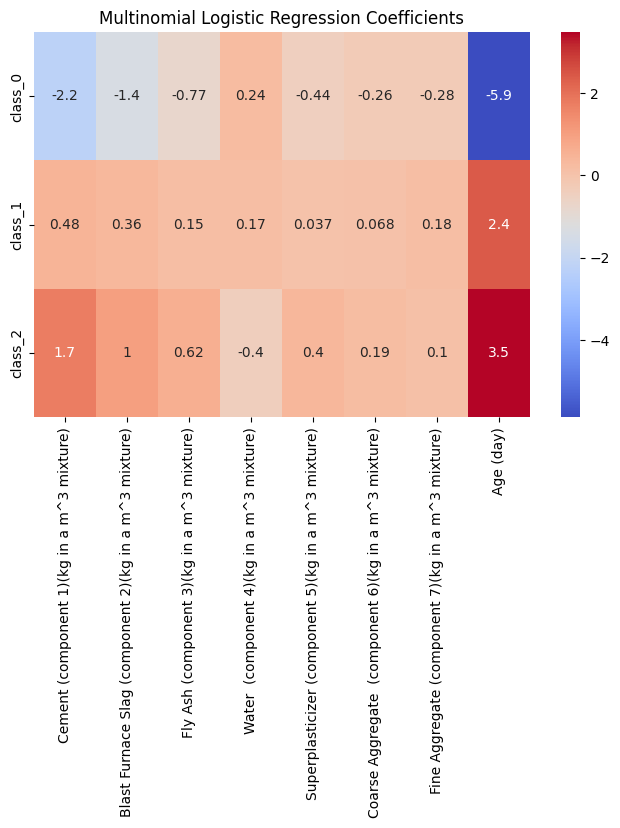

In [ ]:
from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()
X_tr = scaler.fit_transform(X)
final_model = LogisticRegression(C=10, random_state=42, multi_class='multinomial',solver='lbfgs',max_iter=500)
final_model.fit(X_tr, y)
print(final_model.coef_) 

coef_df = pd.DataFrame(
    final_model.coef_,
    columns=X.columns,
    index=[f"class_{c}" for c in np.unique(y)]
)

print("\nFeature importance by class:")
print(coef_df)

mean_abs_importance = coef_df.abs().mean(axis=0).sort_values(ascending=False)
print("\nMean absolute feature importance:")
print(mean_abs_importance)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(coef_df, annot=True, cmap="coolwarm")
plt.title("Multinomial Logistic Regression Coefficients")
plt.show()


In [25]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
import numpy as np

Cs = [0.001, 0.01, 0.1, 1, 10, 100]

kf = KFold(n_splits=10, shuffle=True)
cv_errors = []

scaler = StandardScaler()
X_train = scaler.fit_transform(X)

for C in Cs:
    fold_errors = []

    for train_idx, val_idx in kf.split(X_train, y):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = LogisticRegression(C=C, max_iter=500)
        model.fit(X_tr, y_tr)

        val_pred = model.predict(X_val)
        fold_errors.append(np.mean(val_pred != y_val))

    cv_errors.append(np.mean(fold_errors))

best_C = Cs[np.argmin(cv_errors)]
print("Best C:", best_C)


Best C: 10


In [26]:
import pandas as pd

df_results = pd.DataFrame({
    "C": Cs,
    "Mean_CV_Error": cv_errors,
})

df_results


,C,Mean_CV_Error
0,0.001,0.413921
1,0.010,0.354208
2,0.100,0.312386
3,1.000,0.294436
4,10.000,0.280525
5,100.000,0.281505


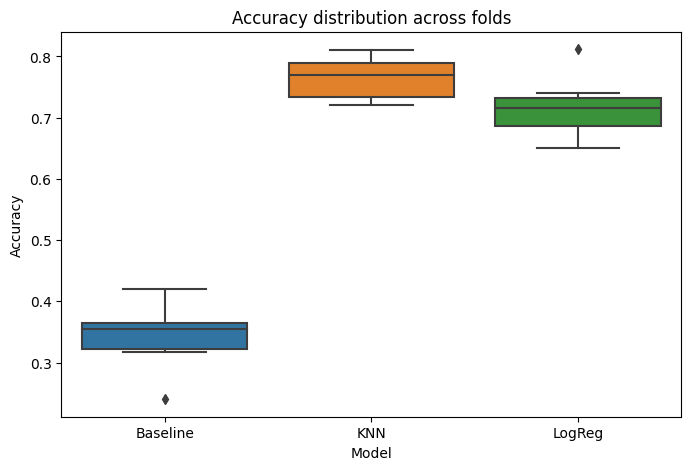

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "fold": list(range(10)),
    "Baseline_Acc": [0.316832, 0.366337, 0.336634, 0.316832, 0.386139,
                     0.35, 0.42, 0.36, 0.24, 0.36],
    "KNN_Acc":      [0.792079, 0.732673, 0.782178, 0.722772, 0.80198,
                     0.77, 0.72, 0.81, 0.74, 0.77],
    "LogReg_Acc":   [0.673267, 0.732673, 0.712871, 0.70297, 0.811881,
                     0.65, 0.74, 0.73, 0.72, 0.68]
}

df = pd.DataFrame(data)

long_df = df.melt(id_vars=["fold"],
                  value_vars=["Baseline_Acc", "KNN_Acc", "LogReg_Acc"],
                  var_name="method",
                  value_name="Accuracy")

long_df["method"] = long_df["method"].str.replace("_Acc", "")

plt.figure(figsize=(8,5))
sns.boxplot(x="method", y="Accuracy", data=long_df)
plt.title("Accuracy distribution across folds")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()
